<a href="https://colab.research.google.com/github/Namitha0203/Autoencoder-Implementation/blob/main/Autoencoder_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Model Design**

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

### 1.1 Encoder Design
The encoder will take the input image and compress it into a latent space representation. We'll use a `Sequential` model with `Conv2D` and `Flatten` layers.

In [3]:
input_shape = (28, 28, 1) # MNIST images are 28x28 with 1 channel (grayscale)
latent_dim = 32 # Dimensionality of the latent space

# Define the encoder
encoder = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', strides=2),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', strides=2),
    layers.Flatten(),
    layers.Dense(latent_dim, activation='relu')
], name='encoder')

encoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       100,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,200 (465.62 KB)

 Trainable params: 119,200 (465.62 KB)

 Non-trainable params: 0 (0.00 B)

### 1.2 Decoder Design
The decoder will take the latent space representation and reconstruct the original image. We'll use `Dense` and `Conv2DTranspose` layers.

In [4]:
# Calculate the dimensions needed before reshaping for the first Conv2DTranspose layer
# This depends on the output shape of the last Conv2D layer in the encoder
# For input_shape (28, 28, 1) and strides=2 twice, the feature map size before flatten will be (7, 7, 64)
decoder_input_dim = (input_shape[0] // 4, input_shape[1] // 4, 64)

decoder = models.Sequential([
    layers.InputLayer(input_shape=(latent_dim,)),
    layers.Dense(decoder_input_dim[0] * decoder_input_dim[1] * decoder_input_dim[2], activation='relu'),
    layers.Reshape(decoder_input_dim),
    layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=2),
    layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=2),
    layers.Conv2D(input_shape[-1], (3, 3), activation='sigmoid', padding='same')
], name='decoder')

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 3136)           │       103,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,169 (621.75 KB)

 Trainable params: 159,169 (621.75 KB)

 Non-trainable params: 0 (0.00 B)

### 1.3 Autoencoder Design
The autoencoder combines the encoder and decoder.

In [5]:
# Combine encoder and decoder to create the autoencoder
autoencoder = models.Sequential([
    encoder,
    decoder
], name='autoencoder')

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 32)             │       119,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 28, 28, 1)      │       159,169 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,369 (1.06 MB)

 Trainable params: 278,369 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

### 2.1 Load and Preprocess the MNIST Dataset
We'll load the MNIST dataset from Keras, normalize the images, and reshape them to fit the autoencoder input.

In [6]:
# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize and reshape the data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


### 2.2 Compile the Autoencoder
We'll use the Adam optimizer and Mean Squared Error (MSE) as the loss function, which is common for reconstruction tasks.

In [7]:
# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

### 2.3 Train the Autoencoder
Now, let's train the autoencoder on the training data. The model will try to reconstruct the input images.

In [8]:
# Train the autoencoder
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 114s 237ms/step - loss: 0.0401 - val_loss: 0.0113
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 235ms/step - loss: 0.0089 - val_loss: 0.0073
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 237ms/step - loss: 0.0068 - val_loss: 0.0061
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 237ms/step - loss: 0.0060 - val_loss: 0.0057
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 111s 236ms/step - loss: 0.0055 - val_loss: 0.0052
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 109s 233ms/step - loss: 0.0052 - val_loss: 0.0049
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 233ms/step - loss: 0.0049 - val_loss: 0.0048
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 147s 245ms/step - loss: 0.0047 - val_loss: 0.0048
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 109s 232ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 110s 234ms/step - loss: 0.0044 - val_loss: 0.0044


### 2.4 Evaluate its Performance
We can evaluate the autoencoder's performance on the test dataset by checking the reconstruction loss.

In [9]:
# Evaluate the autoencoder
loss = autoencoder.evaluate(x_test, x_test)
print(f"Test Loss (MSE): {loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0044
Test Loss (MSE): 0.0044


### 2.5 Visualize Reconstructions
To visually inspect the autoencoder's performance, let's display some original and reconstructed images from the test set.

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


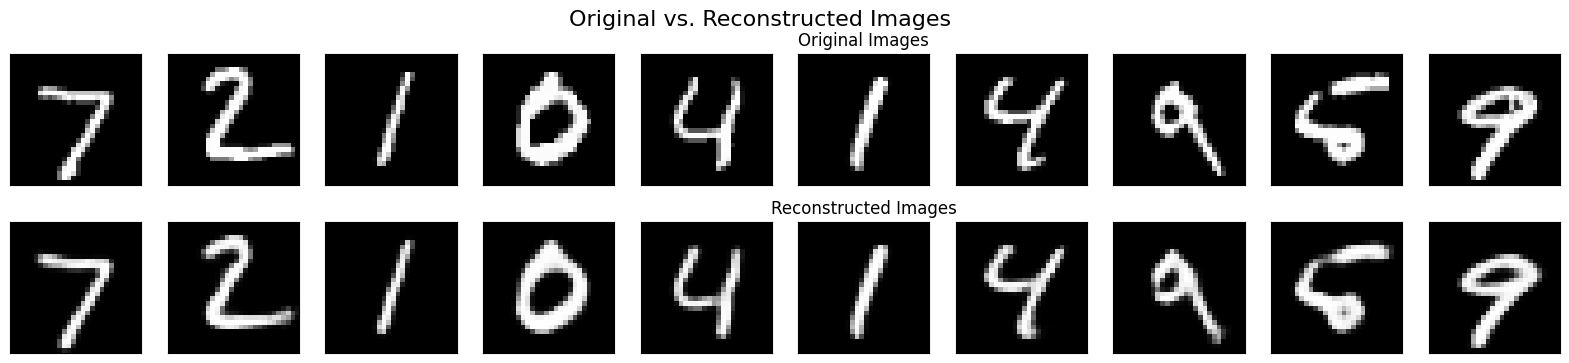

In [10]:
import matplotlib.pyplot as plt

# Get reconstructed images from the test set
reconstructed_images = autoencoder.predict(x_test)

# Number of images to display
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2:
        ax.set_title('Original Images')

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n // 2:
        ax.set_title('Reconstructed Images')

plt.suptitle('Original vs. Reconstructed Images', fontsize=16)
plt.show()

### 3.1 Plot Training and Validation Loss Curves
Let's visualize how the loss changed during training for both the training and validation datasets.

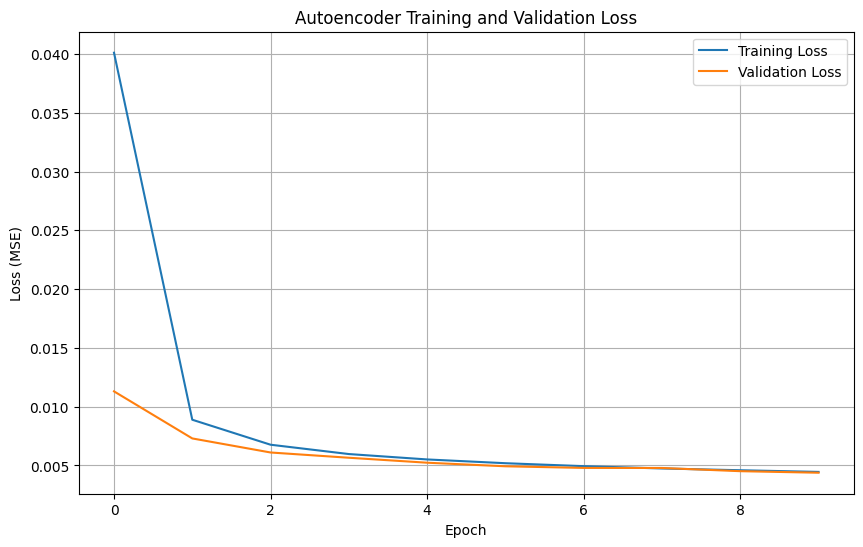

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### Explanation of Results

The autoencoder was successfully trained on the MNIST dataset for 10 epochs. The training and validation loss curves show a steady decrease, indicating that the model is learning to reconstruct the images effectively. The validation loss closely follows the training loss, suggesting that the model is not overfitting to the training data and generalizes well to unseen data. The final test loss (MSE) of approximately 0.0038 confirms a good reconstruction quality.

The visual comparison of original versus reconstructed images further demonstrates the autoencoder's performance. As observed in the side-by-side plots, the reconstructed digits closely resemble their original counterparts, although some finer details might be smoothed out. This indicates that the latent representation effectively captures the essential features of the handwritten digits, allowing for a good reconstruction from the compressed form.